### Analysing results from sweeps
We conducted a sweep to look at the effect of changing the following hyper-parameters and constants:
- Prime constant defining the modular arithmetic task, eg. $p \in [53, \ldots , 97]$ 
- bla 
- bla 

For each run we have the following information:
- LLC curves
- Training and testing loss and accuracy
- Cross-correlation between LLC curves and testing accuracy

We now wish to perform more exploratory analysis. We'll produce a table which looks like this:

| Hyper-parameters and constants | Grokking Test 1 | Grokking Test 2 | Peak of Cross-correlation curve |
|--------------------------------|-----------------|-----------------|---------------------------------|
| p=53, ...                      | Yes             |  Yes            | -1                              |


In [1]:
import os 
import pandas
from utils.metrics import list_lagged_correlation
import numpy as np

In [14]:
sweeps = os.listdir("./results")
df = pandas.DataFrame(columns=["p","lr","weight_decay", "grokking_test1", "max_cross_correlation"])
for i, folder in enumerate(sweeps):
    if folder == "EleutherAI" or folder == "sweep":
        continue
    params = pandas.read_csv(f"./results/{folder}/params.csv")
    loss_data = pandas.read_csv(f"./results/{folder}/loss_data.csv")
    val_acc = loss_data["val_loss"].values
    llc = loss_data["llc"].values
    for column in df.columns:
        if column in params.columns:
            df.loc[i, column] = params[column].values[0]
        
    df.loc[i, "grokking_test1"] = grokking_test1(loss_data["val_acc"].values)
    cross_corr = list_lagged_correlation(llc, val_acc, 10)
    # find index of max cross_corr
    max_index = np.argmax(cross_corr)- 10
    print(cross_corr)
    df.loc[i, "max_cross_correlation"] = max_index

print(df)

[0.8973052192807918, 0.9041316558150867, 0.9094131330890226, 0.9193025299476546, 0.9298989495533138, 0.9446086579810059, 0.9578836528786846, 0.9716048427701387, 0.9840204993824179, 0.9910048816789543, 0.9863300296993432, 0.9770028503217767, 0.9619319357918505, 0.942996138848623, 0.9222831745307983, 0.9015807352014651, 0.881984189694687, 0.8644174787750528, 0.8482590340657978, 0.8337216920813044, 0.8203749588924109]
[0.6906720601531968, 0.7679144260135848, 0.8288447454309003, 0.8759125929481096, 0.9108094119649014, 0.9359975379344951, 0.9565110162951825, 0.9696750771873792, 0.9789742303474659, 0.9814705641953324, 0.9812795022004517, 0.982919463306176, 0.9827940364119142, 0.9808404588875395, 0.9752485776267442, 0.9655559003679335, 0.9506376322329276, 0.9286166224011815, 0.8982419982553265, 0.8563370409176384, 0.8006824906604488]
[0.8927378676878918, 0.9137407153769262, 0.9335875712610596, 0.9519809558727762, 0.9671013504636488, 0.9792417657626824, 0.9881606411335117, 0.9926956708258735, 

In [20]:
sweeps = os.listdir("./results/sweep")
df = pandas.DataFrame(columns=["p", "weight_decay", "grokking_test1"])
for i, folder in enumerate(sweeps):
    params = pandas.read_csv(f"./results/sweep/{folder}/params.csv")
    loss_data = pandas.read_csv(f"./results/sweep/{folder}/loss_data.csv")
    val_acc = loss_data["val_acc"].values
    for column in df.columns:
        if column in params.columns:
            df.loc[i, column] = params[column].values[0]
        
    df.loc[i, "grokking_test1"] = grokking_test1(val_acc)
    df.loc[i, "last_val_acc"] = val_acc[-1]
print(df)

      p weight_decay grokking_test1  last_val_acc
0    13       0.0001          False      0.000000
1    13        0.001          False      0.000000
2    13         0.01          False      0.000000
3    13          0.1          False      0.039216
4    17       0.0001          False      0.011494
..  ...          ...            ...           ...
95  109          0.1          False      0.009819
96  113       0.0001           True      1.000000
97  113        0.001           True      0.997390
98  113         0.01          False      0.008614
99  113          0.1          False      0.008353

[100 rows x 4 columns]


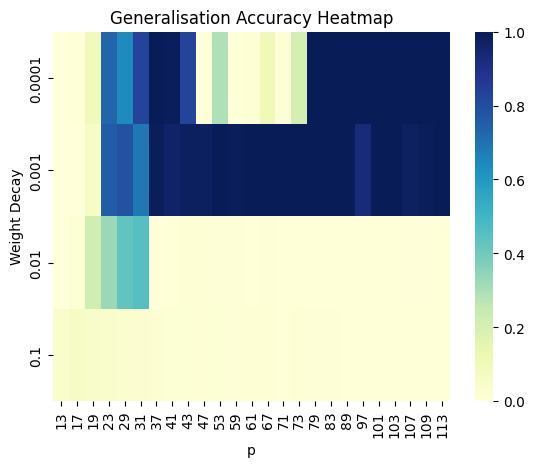

In [23]:
# Convert columns to appropriate types
df["p"] = df["p"].astype(int)
df["weight_decay"] = df["weight_decay"].astype(float)
df["last_val_acc"] = df["last_val_acc"].astype(float)

pivot_table = df.pivot(index="weight_decay", columns="p", values="last_val_acc")
sns.heatmap(pivot_table, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Generalisation Accuracy Heatmap")
plt.xlabel("p")
plt.ylabel("Weight Decay")
plt.show()

In [36]:
import pandas
import os
import numpy as np
from utils.metrics import grokking_test2, grokking_test3, list_lagged_correlation
sweeps = os.listdir("./results/sweep2")
df = pandas.DataFrame(columns=["p", "embed_dim"])
for i, folder in enumerate(sweeps):
    params = pandas.read_csv(f"./results/sweep2/{folder}/params.csv")
    loss_data = pandas.read_csv(f"./results/sweep2/{folder}/loss_data.csv")
    val_acc = loss_data["val_acc"].values
    for column in df.columns:
        if column in params.columns:
            df.loc[i, column] = params[column].values[0]
        
    df.loc[i, "grokking_test2"] = grokking_test2(loss_data["train_acc"].values, val_acc)
    df.loc[i, "grokking_test3"] = grokking_test3(loss_data["train_acc"].values, val_acc)
    df.loc[i, "last_val_acc"] = val_acc[-1]
    df.loc[i, "time_-20_val_acc"] = val_acc[-20]
    df.loc[i, "time_-50_val_acc"] = val_acc[-50]
    df.loc[i, "max_corr_idx"] = np.argmax(list_lagged_correlation(loss_data["llc"].values, loss_data["val_loss"].values, 10)) - 10
    df.loc[i, "max_corr"] = np.max(list_lagged_correlation(loss_data["llc"].values, loss_data["val_loss"].values, 10))
    df.loc[i, "min_corr"] = np.min(list_lagged_correlation(loss_data["llc"].values, loss_data["val_loss"].values, 10))
    df.loc[i, "min_corr_idx"] = np.argmin(list_lagged_correlation(loss_data["llc"].values, loss_data["val_loss"].values, 10)) - 10
    df.loc[i, "final_llc"] = loss_data["llc"].values[-1]

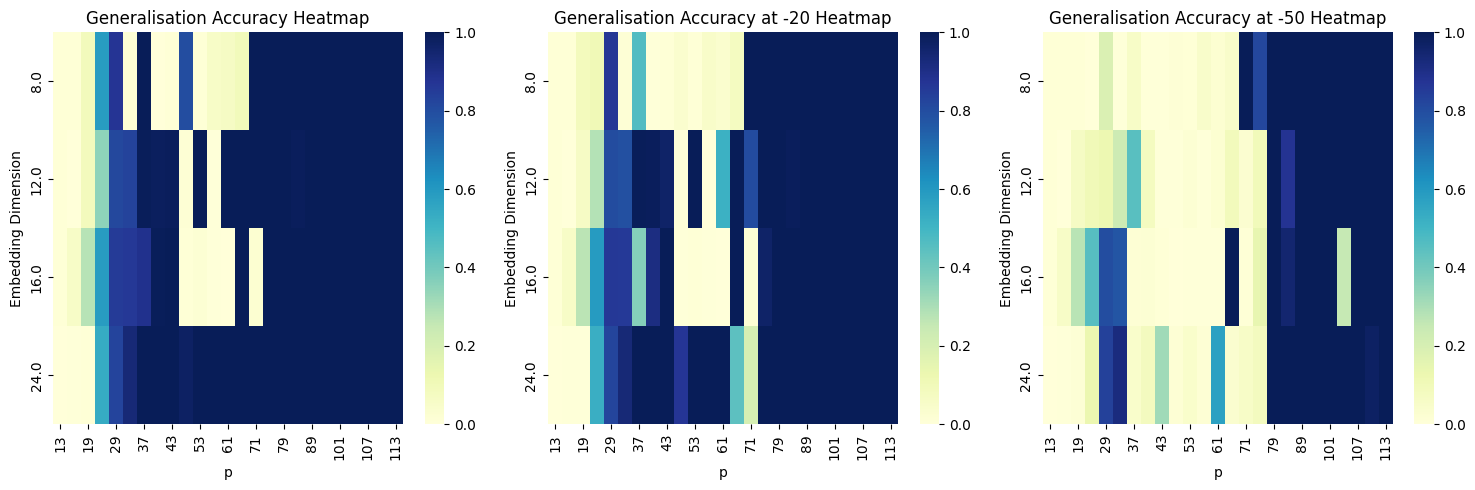

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
# Convert columns to appropriate types
df["p"] = df["p"].astype(int)
df["embed_dim"] = df["embed_dim"].astype(float)
df["last_val_acc"] = df["last_val_acc"].astype(float)

# 3 subfigures side by side
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
pivot_table_0 = df.pivot(index="embed_dim", columns="p", values="last_val_acc")
sns.heatmap(pivot_table_0, cmap="YlGnBu", annot=False, cbar=True, ax=axs[0])
axs[0].set_title("Generalisation Accuracy Heatmap")
axs[0].set_xlabel("p")
axs[0].set_ylabel("Embedding Dimension")
pivot_table_1 = df.pivot(index="embed_dim", columns="p", values="time_-20_val_acc")
sns.heatmap(pivot_table_1, cmap="YlGnBu", annot=False, cbar=True, ax=axs[1])
axs[1].set_title("Generalisation Accuracy at -20 Heatmap")
axs[1].set_xlabel("p")
axs[1].set_ylabel("Embedding Dimension")
pivot_table_2 = df.pivot(index="embed_dim", columns="p", values="time_-50_val_acc")
sns.heatmap(pivot_table_2, cmap="YlGnBu", annot=False, cbar=True, ax=axs[2])
axs[2].set_title("Generalisation Accuracy at -50 Heatmap")
axs[2].set_xlabel("p")
axs[2].set_ylabel("Embedding Dimension")
plt.tight_layout()
plt.show()

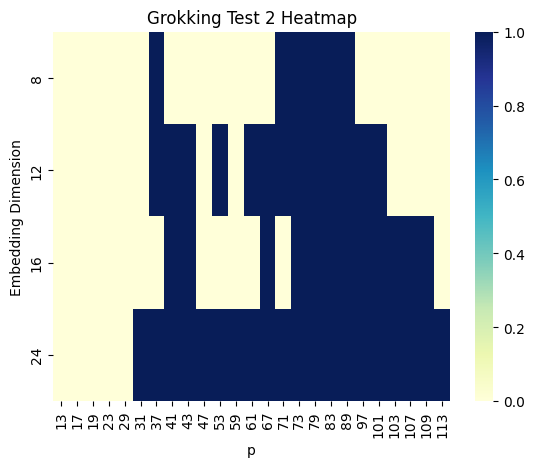

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# plot heat map with grokking_test2
df["grokking_test2"] = df["grokking_test2"].astype(bool)
pivot_table = df.pivot(index="embed_dim", columns="p", values="grokking_test2")
sns.heatmap(pivot_table, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Grokking Test 2 Heatmap")
plt.xlabel("p")
plt.ylabel("Embedding Dimension")
plt.show()

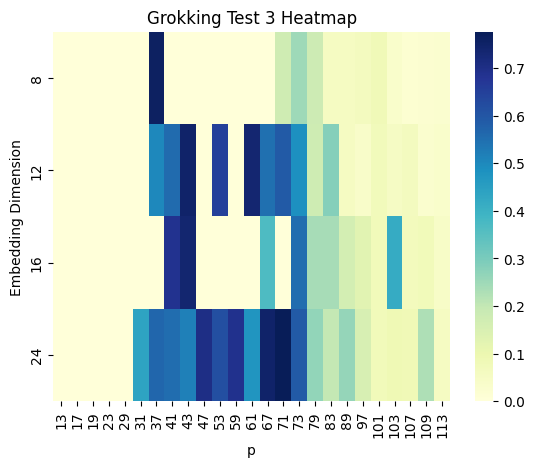

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# plot heat map with grokking_test3
df["grokking_test3"] = df["grokking_test3"].astype(float)
pivot_table = df.pivot(index="embed_dim", columns="p", values="grokking_test3")
sns.heatmap(pivot_table, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Grokking Test 3 Heatmap")
plt.xlabel("p")
plt.ylabel("Embedding Dimension")
plt.show()

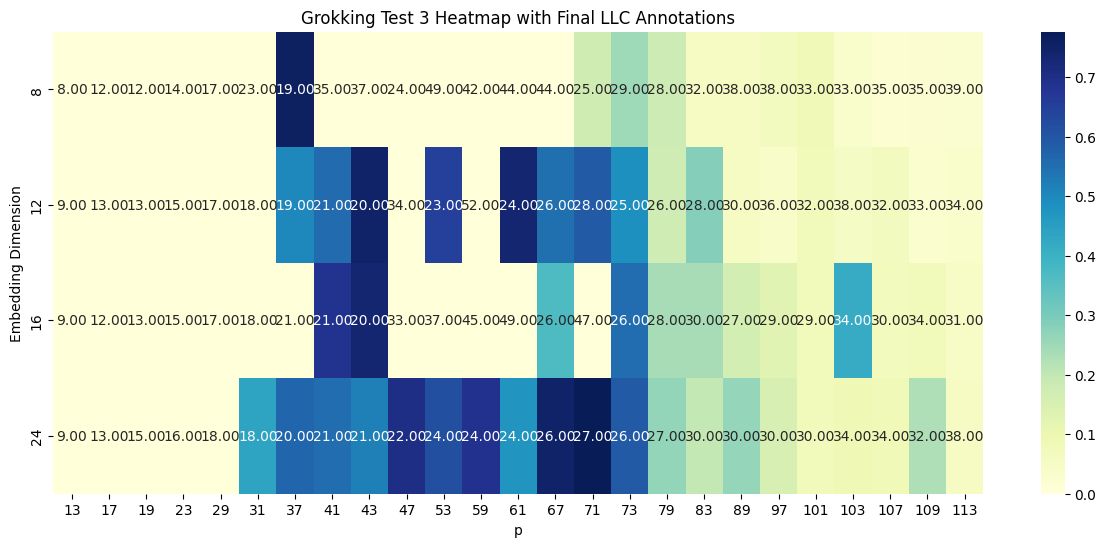

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure numeric values
df["grokking_test3"] = df["grokking_test3"].astype(float)
df["final_llc"] = df["final_llc"].round()

# Create pivot tables
pivot_grok = df.pivot(index="embed_dim", columns="p", values="grokking_test3")
pivot_corr = df.pivot(index="embed_dim", columns="p", values="final_llc")

# Plot heatmap
plt.figure(figsize=(15,6))
sns.heatmap(
    pivot_grok,
    cmap="YlGnBu",
    annot=pivot_corr,       # show max_corr values inside boxes
    fmt=".2f",              # format numbers (2 decimals)
    cbar=True
)

plt.title("Grokking Test 3 Heatmap with Final LLC Annotations")
plt.xlabel("p")
plt.ylabel("Embedding Dimension")
plt.show()


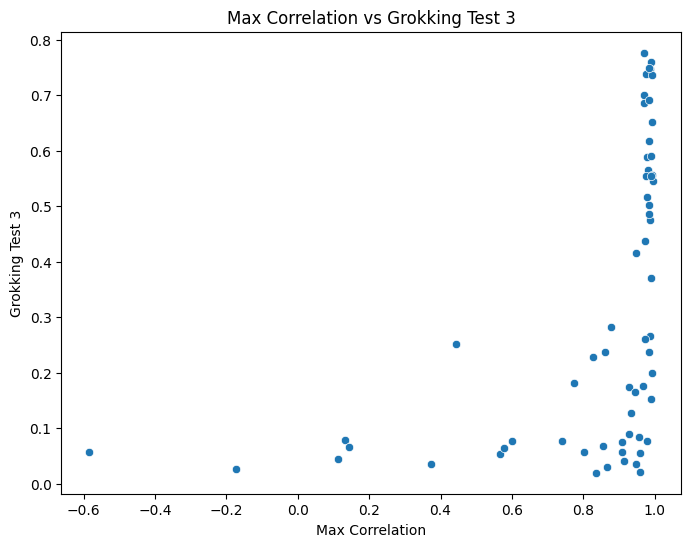

In [25]:
# plot df[max_corr_idx] against df[grokking_test3] 
plt.figure(figsize=(8,6))
sns.scatterplot(data=df[df["grokking_test3"] > 0], x="max_corr", y="grokking_test3")
plt.title("Max Correlation vs Grokking Test 3")
plt.xlabel("Max Correlation")
plt.ylabel("Grokking Test 3")
plt.show()

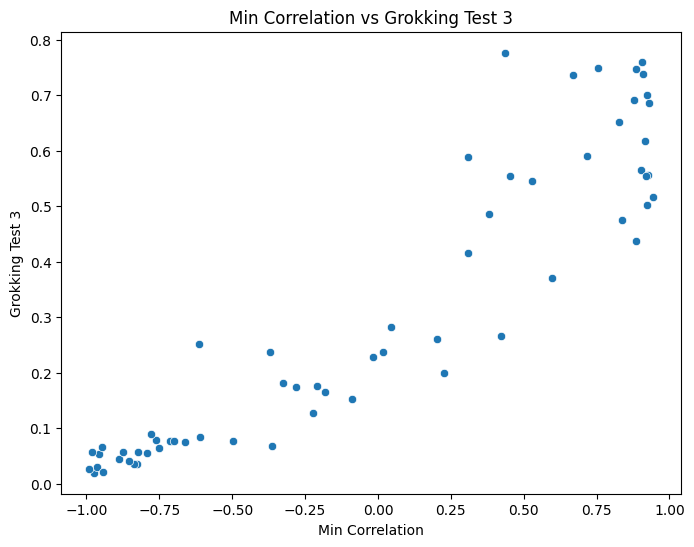

In [26]:
# plot df[min_corr_idx] against df[grokking_test3] if grokking is above 0.2
plt.figure(figsize=(8,6))
sns.scatterplot(data=df[df["grokking_test3"] > 0], x="min_corr", y="grokking_test3")
plt.title("Min Correlation vs Grokking Test 3")
plt.xlabel("Min Correlation")
plt.ylabel("Grokking Test 3")
plt.show()

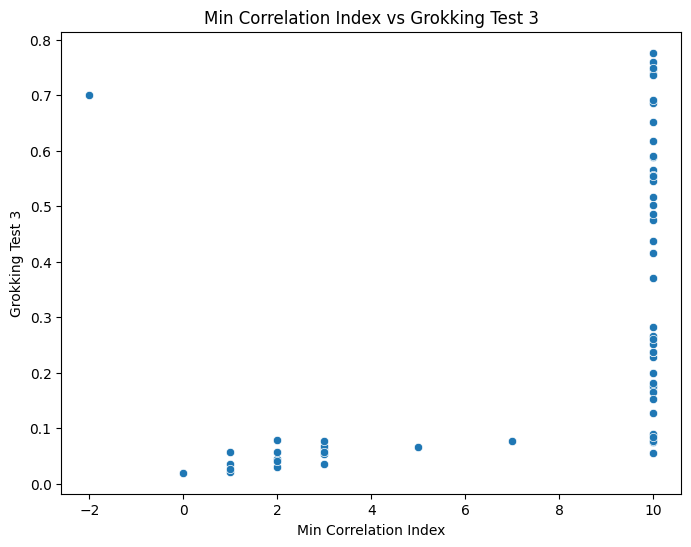

In [27]:
# plot df[min_corr_idx] against df[grokking_test3] if grokking is above 0.2
plt.figure(figsize=(8,6))
sns.scatterplot(data=df[df["grokking_test3"] > 0], x="min_corr_idx", y="grokking_test3")
plt.title("Min Correlation Index vs Grokking Test 3")
plt.xlabel("Min Correlation Index")
plt.ylabel("Grokking Test 3")
plt.show()

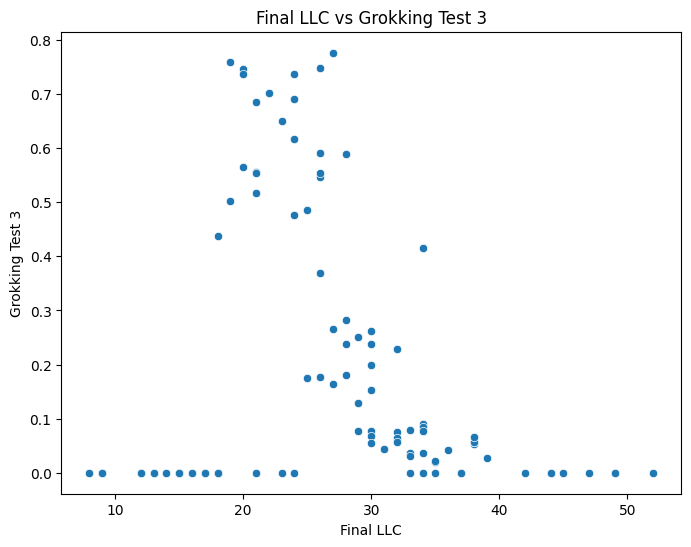

In [45]:
# plot df[min_corr_idx] against df[grokking_test3] if grokking is above 0.2
plt.figure(figsize=(8,6))
sns.scatterplot(data=df[df["grokking_test3"]>-1], x="final_llc", y="grokking_test3")
plt.title("Final LLC vs Grokking Test 3")
plt.xlabel("Final LLC")
plt.ylabel("Grokking Test 3")
plt.show()

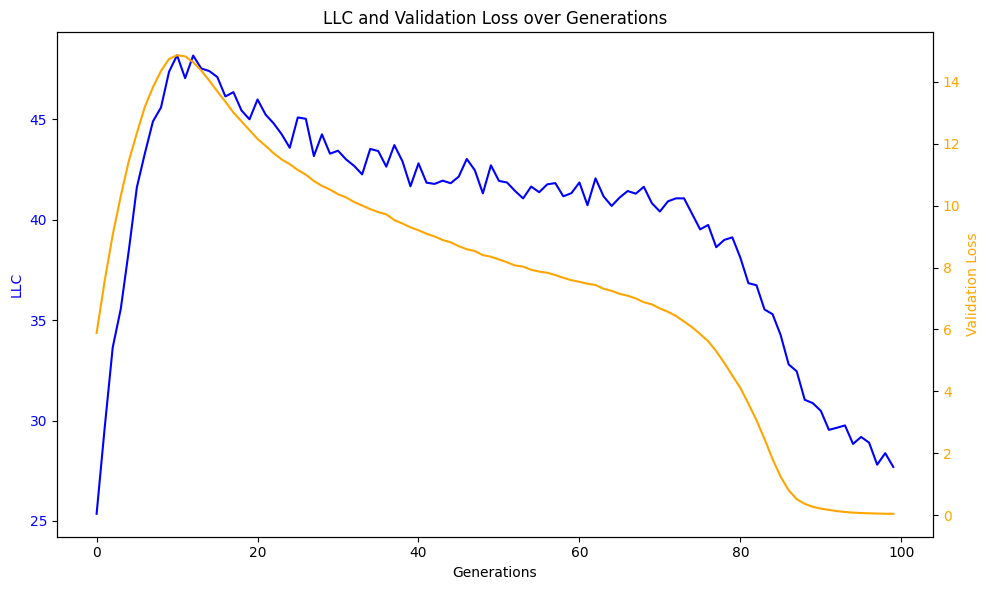

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_csv("/home/se24/geom_phase_transitions/results/sweep2/p=71_embed=24/loss_data.csv")
llc = df["llc"].values
val_loss = df["val_loss"].values

# Create figure and first axis
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot LLC on the left y-axis
ax1.plot(llc, color='blue', label='LLC')
ax1.set_xlabel("Generations")
ax1.set_ylabel("LLC", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(val_loss, color='orange', label='Validation Loss')
ax2.set_ylabel("Validation Loss", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Title and layout
plt.title("LLC and Validation Loss over Generations")
fig.tight_layout()
plt.show()
